# Google Trends Alpha — NSE Large Caps

**Hypothesis:** Retail investor search interest on Google (a proxy for attention and sentiment) contains predictive information about future stock returns on NSE.

**Method:**
1. Pull weekly Google Trends search volume for 8 NSE large caps
2. Test Granger causality — does search volume Granger-cause returns?
3. Build a long-short alpha strategy based on normalized trends signal
4. Backtest and evaluate

**Universe:** RELIANCE, TCS, HDFCBANK, INFY, ICICIBANK, WIPRO, SBIN, BAJFINANCE  
**Period:** 2018 – 2024  
**Frequency:** Weekly

---

## 1. Setup & Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import yfinance as yf
import time
import warnings
warnings.filterwarnings('ignore')

from pytrends.request import TrendReq
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# --- Universe ---
STOCKS = {
    'RELIANCE':  'RELIANCE.NS',
    'TCS':       'TCS.NS',
    'HDFCBANK':  'HDFCBANK.NS',
    'INFY':      'INFY.NS',
    'ICICIBANK': 'ICICIBANK.NS',
    'WIPRO':     'WIPRO.NS',
    'SBIN':      'SBIN.NS',
    'BAJFINANCE':'BAJFINANCE.NS',
}

START = '2018-01-01'
END   = '2024-12-31'
MAX_LAG = 4   # weeks

print(f'Universe: {list(STOCKS.keys())}')
print('Libraries loaded.')

Universe: ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ICICIBANK', 'WIPRO', 'SBIN', 'BAJFINANCE']
Libraries loaded.


## 2. Data Collection
### 2.1 Google Trends (weekly search volume)

In [14]:
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

TRENDS_CACHE = '../data/trends_raw.csv'

def fetch_trends_yearly(keywords, start_year, end_year, geo='IN', sleep=5):
    """
    Fetch weekly Google Trends year by year (avoids monthly aggregation).
    pytrends returns weekly data only for ranges < ~9 months.
    """
    from pytrends.request import TrendReq
    pytrends = TrendReq(hl='en-US', tz=330)
    all_dfs = []

    for year in range(start_year, end_year + 1):
        timeframe = f'{year}-01-01 {year}-12-31'
        batches = [keywords[i:i+5] for i in range(0, len(keywords), 5)]
        year_dfs = []
        for batch in batches:
            try:
                pytrends.build_payload(batch, timeframe=timeframe, geo=geo)
                df = pytrends.interest_over_time()
                if 'isPartial' in df.columns:
                    df = df.drop(columns=['isPartial'])
                year_dfs.append(df)
                time.sleep(sleep)
            except Exception as e:
                print(f'Error {year} {batch}: {e}')
                time.sleep(10)
        if year_dfs:
            all_dfs.append(pd.concat(year_dfs, axis=1))
        print(f'Done {year}: {len(all_dfs[-1]) if all_dfs else 0} weeks')

    return pd.concat(all_dfs).sort_index()

if os.path.exists(TRENDS_CACHE):
    print('Loading trends from cache...')
    trends_raw = pd.read_csv(TRENDS_CACHE, index_col=0, parse_dates=True)
else:
    print('Fetching from Google Trends API year by year...')
    trends_raw = fetch_trends_yearly(list(STOCKS.keys()), 2018, 2024)
    trends_raw = trends_raw[~trends_raw.index.duplicated(keep='first')]
    trends_raw.to_csv(TRENDS_CACHE)
    print('Saved to cache.')

print(f'Trends shape: {trends_raw.shape}')
print(f'Period: {trends_raw.index[0].date()} → {trends_raw.index[-1].date()}')
trends_raw.head()

Loading trends from cache...
Trends shape: (366, 8)
Period: 2017-12-31 → 2024-12-29


,RELIANCE,TCS,HDFCBANK,INFY,ICICIBANK,WIPRO,SBIN,BAJFINANCE
date,,,,,,,,
2017-12-31,100,22,5,1,4,59,10,0
2018-01-07,92,32,5,3,4,67,11,0
2018-01-14,87,41,5,2,4,71,12,0
2018-01-21,89,37,4,2,3,62,11,0
2018-01-28,83,37,5,2,5,67,12,0


### 2.2 Price Data (weekly returns)

In [15]:
PRICES_CACHE = '../data/prices_weekly.csv'

if os.path.exists(PRICES_CACHE):
    print('Loading prices from cache...')
    prices = pd.read_csv(PRICES_CACHE, index_col=0, parse_dates=True)
else:
    print('Downloading from yfinance...')
    tickers = list(STOCKS.values())
    raw = yf.download(tickers, start=START, end=END,
                      auto_adjust=True, progress=False)

    # Handle MultiIndex
    if isinstance(raw.columns, pd.MultiIndex):
        close = raw['Close']
    else:
        close = raw[['Close']]

    # Rename columns from ticker to stock name
    ticker_to_name = {v: k for k, v in STOCKS.items()}
    close.columns = [ticker_to_name.get(c, c) for c in close.columns]

    # Resample to weekly (Friday close)
    prices = close.resample('W-FRI').last()
    prices.to_csv(PRICES_CACHE)
    print('Saved to cache.')

# Weekly returns
returns = prices.pct_change().dropna()

print(f'Prices shape : {prices.shape}')
print(f'Returns shape: {returns.shape}')
prices.head()

Loading prices from cache...
Prices shape : (366, 8)
Returns shape: (365, 8)


,BAJFINANCE,HDFCBANK,ICICIBANK,INFY,RELIANCE,SBIN,TCS,WIPRO
Date,,,,,,,,
2018-01-05,176.720154,434.812225,300.552460,397.974274,405.951202,277.669220,1086.894897,105.930626
2018-01-12,172.395889,435.208893,305.163025,424.106018,417.273468,273.953064,1122.118408,109.096062
2018-01-19,165.753662,455.484253,339.646393,449.667633,409.490814,280.297699,1196.061401,112.569473
2018-01-26,166.571808,460.792206,346.562225,462.232178,424.704376,283.832581,1264.426880,106.751915
2018-02-02,158.643951,454.504272,321.876434,449.589050,397.640930,269.511810,1277.633789,103.203712


### 2.3 Align Trends & Returns

In [17]:
print(f'Trends index sample: {trends_z.index[:3]}')
print(f'Returns index sample: {returns.index[:3]}')
print(f'Trends shape: {trends_z.shape}')
print(f'Returns shape: {returns.shape}')
print(f'Common index size: {len(common_idx)}')

Trends index sample: DatetimeIndex(['2017-12-31', '2018-01-07', '2018-01-14'], dtype='datetime64[us]', name='date', freq=None)
Returns index sample: DatetimeIndex(['2018-01-12', '2018-01-19', '2018-01-26'], dtype='datetime64[us]', name='Date', freq=None)
Trends shape: (366, 8)
Returns shape: (365, 8)
Common index size: 0


In [18]:
# Normalize both indices to Monday (week start) for alignment
trends_z.index = pd.to_datetime(trends_z.index) + pd.offsets.Week(weekday=0) - pd.offsets.Week()
returns.index  = pd.to_datetime(returns.index)  + pd.offsets.Week(weekday=0) - pd.offsets.Week()

# Drop duplicates that may arise from rounding
trends_z = trends_z[~trends_z.index.duplicated(keep='first')]
returns  = returns[~returns.index.duplicated(keep='first')]

# Align on common weekly index
common_idx = trends_z.index.intersection(returns.index)
T = trends_z.loc[common_idx]
R = returns.loc[common_idx]

# Ensure same columns
cols = [c for c in STOCKS.keys() if c in T.columns and c in R.columns]
T = T[cols]
R = R[cols]

print(f'Aligned shape: {T.shape}')
print(f'Stocks: {cols}')
print(f'Period: {T.index[0].date()} → {T.index[-1].date()}')

Aligned shape: (364, 8)
Stocks: ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ICICIBANK', 'WIPRO', 'SBIN', 'BAJFINANCE']
Period: 2018-01-08 → 2024-12-23


## 3. Exploratory Analysis
### 3.1 Trends vs Price

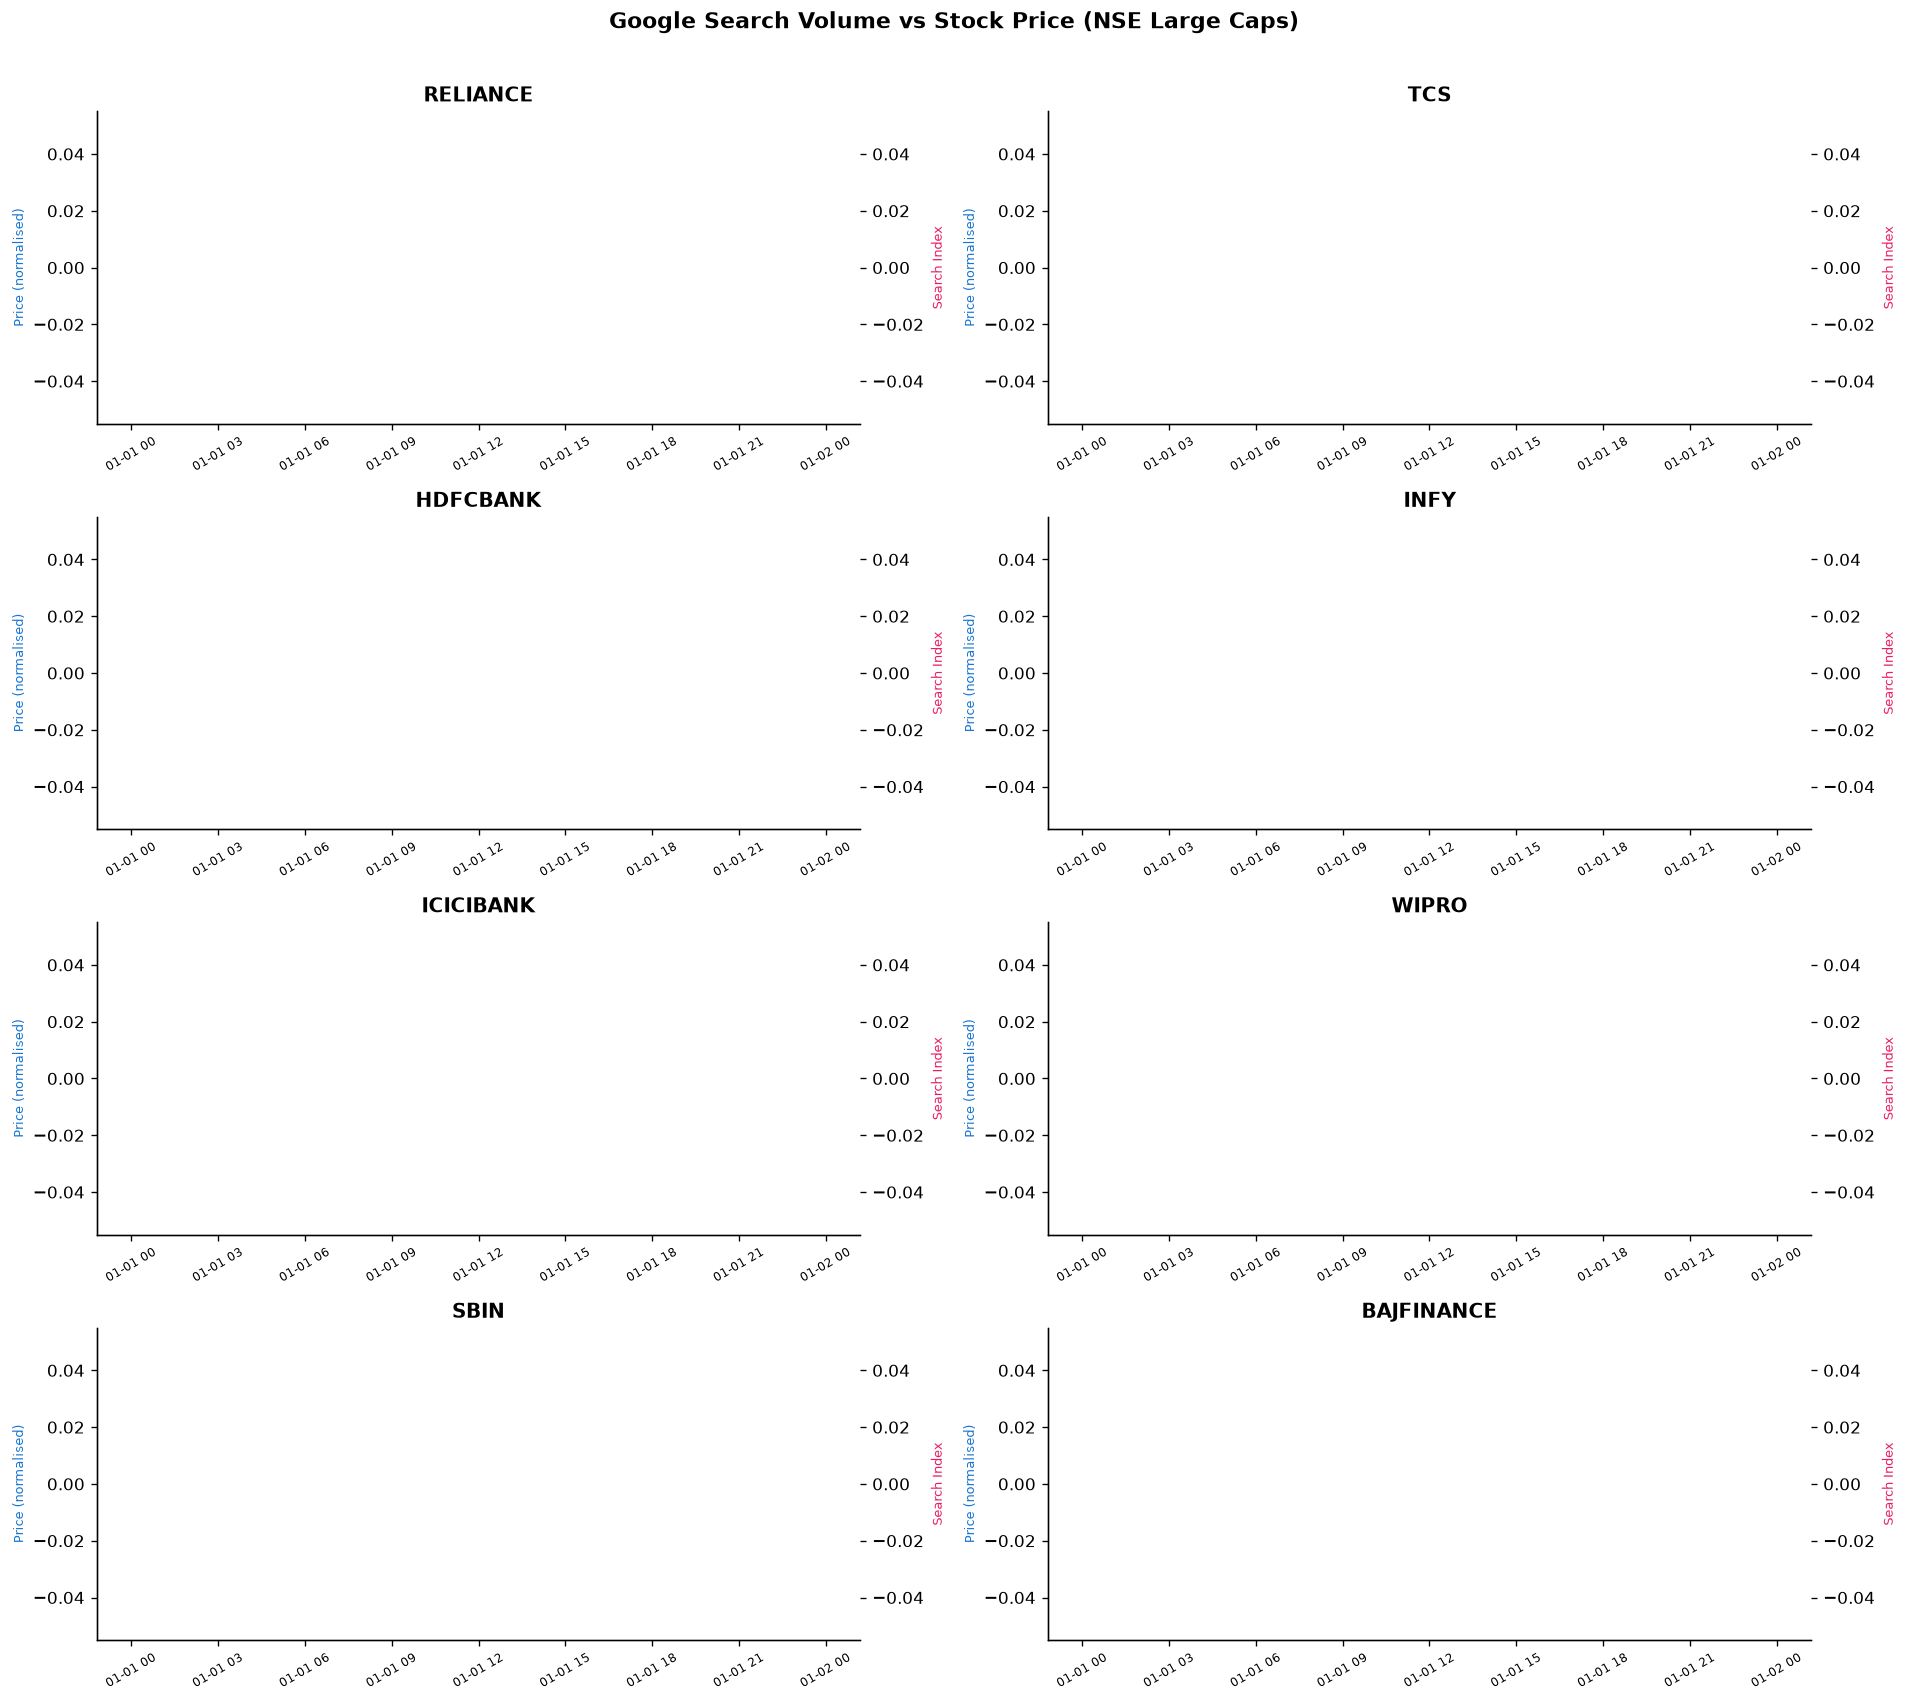

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, stock in enumerate(cols):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # Normalize price for visual comparison
    price_norm = prices[stock] / prices[stock].iloc[0]
    price_norm = price_norm.reindex(T.index).dropna()

    ax1.plot(price_norm.index, price_norm.values,
             color='#1976D2', linewidth=1.5, label='Price (norm)')
    ax2.plot(T.index, trends_raw[stock].reindex(T.index),
             color='#E91E63', linewidth=1, alpha=0.7, label='Search Volume')

    ax1.set_title(stock, fontweight='bold')
    ax1.set_ylabel('Price (normalised)', color='#1976D2', fontsize=8)
    ax2.set_ylabel('Search Index', color='#E91E63', fontsize=8)
    ax1.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Google Search Volume vs Stock Price (NSE Large Caps)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/trends_vs_price.png', bbox_inches='tight')
plt.show()

## 4. Granger Causality Tests

**Null hypothesis:** Search volume does NOT Granger-cause stock returns.  
**We reject H0** (p < 0.05) → search volume has predictive content for returns.

Note: Granger causality ≠ true causality. It only means past search volume improves the forecast of returns beyond lagged returns alone.

In [20]:
def granger_pvalue(trends_series, returns_series, max_lag=4):
    """
    Run Granger causality test: does trends Granger-cause returns?
    Returns min p-value across lags (most significant lag).
    """
    df = pd.DataFrame({'returns': returns_series, 'trends': trends_series}).dropna()
    if len(df) < max_lag * 3:
        return np.nan
    try:
        result = grangercausalitytests(df[['returns', 'trends']], maxlag=max_lag, verbose=False)
        pvals = [result[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag + 1)]
        return min(pvals)  # most significant lag
    except Exception:
        return np.nan

# Run for all stocks and lag directions
print('Running Granger causality tests...')
granger_results = {}

for stock in cols:
    p_trends_to_returns = granger_pvalue(T[stock], R[stock], MAX_LAG)
    p_returns_to_trends = granger_pvalue(R[stock], T[stock], MAX_LAG)  # reverse
    granger_results[stock] = {
        'p_trends→returns': p_trends_to_returns,
        'p_returns→trends': p_returns_to_trends,
        'significant':      p_trends_to_returns < 0.05
    }
    sig = '✓ SIGNIFICANT' if p_trends_to_returns < 0.05 else '✗'
    print(f'{stock:12s} | trends→returns p={p_trends_to_returns:.4f} {sig}')

granger_df = pd.DataFrame(granger_results).T
print(f'\nStocks where trends Granger-cause returns: '
      f'{granger_df["significant"].sum()}/{len(cols)}')

Running Granger causality tests...
RELIANCE     | trends→returns p=0.2982 ✗
TCS          | trends→returns p=0.0263 ✓ SIGNIFICANT
HDFCBANK     | trends→returns p=0.2466 ✗
INFY         | trends→returns p=0.0067 ✓ SIGNIFICANT
ICICIBANK    | trends→returns p=0.1542 ✗
WIPRO        | trends→returns p=0.5204 ✗
SBIN         | trends→returns p=0.0042 ✓ SIGNIFICANT
BAJFINANCE   | trends→returns p=0.5174 ✗

Stocks where trends Granger-cause returns: True/8


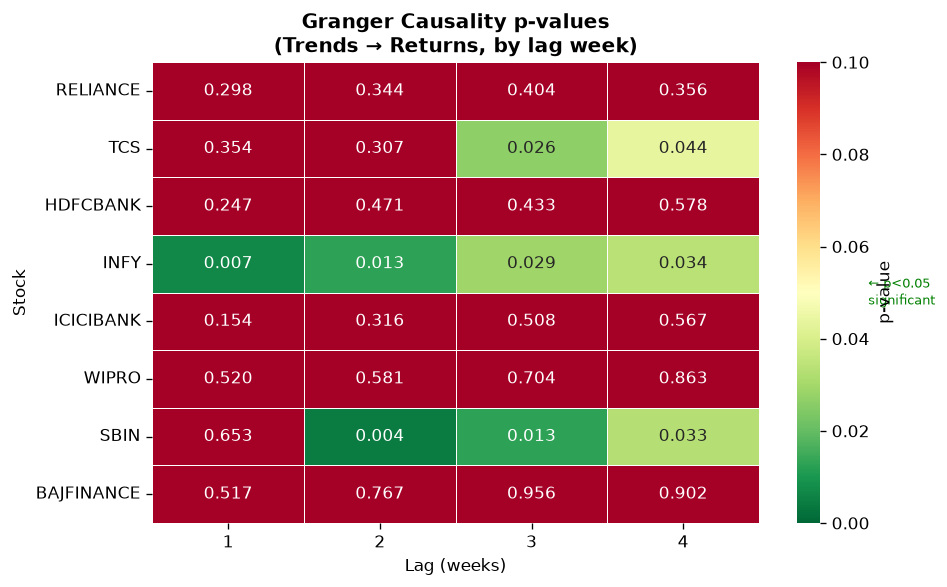

In [21]:
# --- Granger p-value heatmap by lag ---
lag_pvals = pd.DataFrame(index=cols, columns=range(1, MAX_LAG+1), dtype=float)

for stock in cols:
    df = pd.DataFrame({'returns': R[stock], 'trends': T[stock]}).dropna()
    try:
        result = grangercausalitytests(df[['returns', 'trends']], maxlag=MAX_LAG, verbose=False)
        for lag in range(1, MAX_LAG+1):
            lag_pvals.loc[stock, lag] = result[lag][0]['ssr_ftest'][1]
    except:
        pass

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    lag_pvals.astype(float),
    annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=0, vmax=0.1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'p-value'}
)
ax.set_title('Granger Causality p-values\n(Trends → Returns, by lag week)',
             fontweight='bold')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Stock')

# Add significance line annotation
ax.text(1.18, 0.5, '← p<0.05\nsignificant',
        transform=ax.transAxes, fontsize=8,
        color='green', va='center')

plt.tight_layout()
plt.savefig('../figures/granger_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Alpha Signal Construction

**Signal:** For each week, rank stocks by their lagged z-score search volume.  
**Position:** Long top 3 / Short bottom 3 (equal weight within each leg).  
**Lag:** 1 week (signal at week t → position entered at week t+1)

In [22]:
print(f'T shape: {T.shape}')
print(f'R shape: {R.shape}')
print(f'T index sample: {T.index[:5]}')
print(f'R index sample: {R.index[:5]}')
print(f'Common index size: {len(common_idx)}')

T shape: (364, 8)
R shape: (364, 8)
T index sample: DatetimeIndex(['2018-01-08', '2018-01-15', '2018-01-22', '2018-01-29',
               '2018-02-05'],
              dtype='datetime64[us]', freq=None)
R index sample: DatetimeIndex(['2018-01-08', '2018-01-15', '2018-01-22', '2018-01-29',
               '2018-02-05'],
              dtype='datetime64[us]', freq=None)
Common index size: 364


In [23]:
LONG_N  = 3
SHORT_N = 3

# Signal: lagged 1-week z-score trends
signal = T.shift(1)   # use last week's search volume to predict this week

# Cross-sectional rank → normalized weight
def rank_signal(row):
    """Long top N, short bottom N, zero otherwise."""
    ranked = row.rank(ascending=False)
    n = len(row.dropna())
    weights = pd.Series(0.0, index=row.index)
    weights[ranked <= LONG_N]        =  1.0 / LONG_N
    weights[ranked > (n - SHORT_N)]  = -1.0 / SHORT_N
    return weights

weights = signal.apply(rank_signal, axis=1)

# Strategy returns
strat_returns = (weights * R).sum(axis=1)
warmup = min(52, len(T) // 4)
strat_returns = strat_returns.loc[strat_returns.index >= T.index[warmup]]  

print(f'Strategy period: {strat_returns.index[0].date()} → {strat_returns.index[-1].date()}')
print(f'Weeks: {len(strat_returns)}')
print(f'Mean weekly return: {strat_returns.mean()*100:.3f}%')

Strategy period: 2019-01-07 → 2024-12-23
Weeks: 312
Mean weekly return: 0.246%


## 6. Information Coefficient (IC)

IC = rank correlation between signal and next-period returns.  
IC > 0.05 is considered meaningful for a weekly alpha signal.

In [24]:
ic_series = []
for date in strat_returns.index:
    if date not in signal.index or date not in R.index:
        continue
    s = signal.loc[date].dropna()
    r = R.loc[date].dropna()
    common = s.index.intersection(r.index)
    if len(common) < 4:
        continue
    ic, _ = stats.spearmanr(s[common], r[common])
    ic_series.append({'date': date, 'ic': ic})

ic_df = pd.DataFrame(ic_series).set_index('date')
mean_ic  = ic_df['ic'].mean()
ic_ir    = ic_df['ic'].mean() / ic_df['ic'].std()  # IC Information Ratio

print(f'Mean IC  : {mean_ic:.4f}')
print(f'IC IR    : {ic_ir:.4f}')
print(f'IC > 0   : {(ic_df["ic"] > 0).mean()*100:.1f}% of weeks')

Mean IC  : 0.0437
IC IR    : 0.1001
IC > 0   : 53.5% of weeks


## 7. Backtest & Visualisation

In [25]:
def performance_metrics(returns, label='Strategy', freq=52):
    ann_ret = returns.mean() * freq
    ann_vol = returns.std()  * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + returns).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    print(f'\n=== {label} ===')
    print(f'  Ann. Return  : {ann_ret*100:+.2f}%')
    print(f'  Ann. Vol     : {ann_vol*100:.2f}%')
    print(f'  Sharpe Ratio : {sharpe:.3f}')
    print(f'  Max Drawdown : {max_dd*100:.2f}%')
    print(f'  Calmar Ratio : {calmar:.3f}')
    return dict(label=label, ann_ret=ann_ret, ann_vol=ann_vol,
                sharpe=sharpe, max_dd=max_dd, calmar=calmar)

# Nifty benchmark (equal weight buy & hold)
bh_returns = R.loc[strat_returns.index].mean(axis=1)

m_strat = performance_metrics(strat_returns, 'Long-Short Trends Alpha')
m_bh    = performance_metrics(bh_returns,    'Equal Weight Buy & Hold')


=== Long-Short Trends Alpha ===
  Ann. Return  : +12.79%
  Ann. Vol     : 22.67%
  Sharpe Ratio : 0.564
  Max Drawdown : -34.85%
  Calmar Ratio : 0.367

=== Equal Weight Buy & Hold ===
  Ann. Return  : +20.87%
  Ann. Vol     : 19.74%
  Sharpe Ratio : 1.058
  Max Drawdown : -36.08%
  Calmar Ratio : 0.579


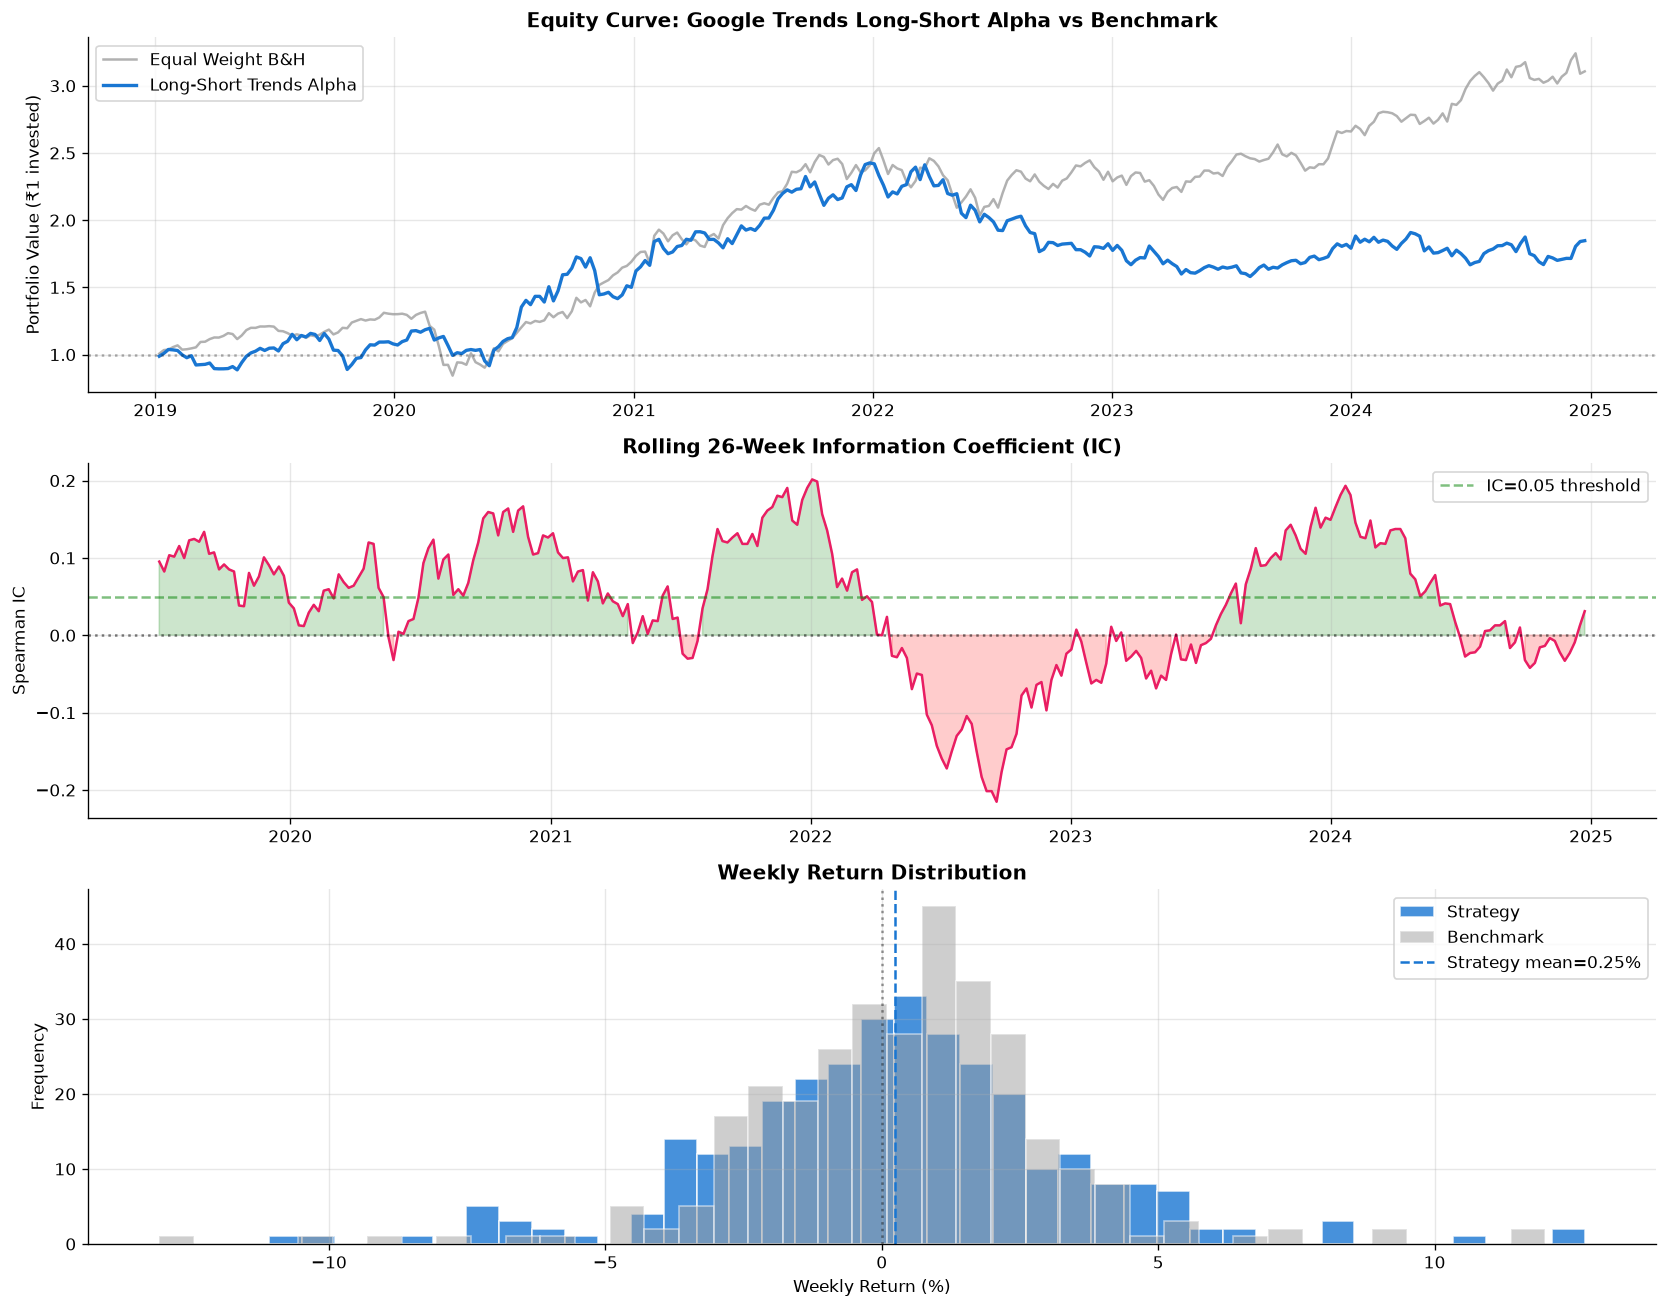

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# --- Panel 1: Equity Curves ---
eq_strat = (1 + strat_returns).cumprod()
eq_bh    = (1 + bh_returns).cumprod()

axes[0].plot(eq_bh.index,    eq_bh.values,    color='#9E9E9E', linewidth=1.5,
             label='Equal Weight B&H', alpha=0.8)
axes[0].plot(eq_strat.index, eq_strat.values, color='#1976D2', linewidth=2,
             label='Long-Short Trends Alpha')
axes[0].axhline(1.0, color='black', linestyle=':', alpha=0.3)
axes[0].set_title('Equity Curve: Google Trends Long-Short Alpha vs Benchmark',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: Rolling IC (26-week) ---
rolling_ic = ic_df['ic'].rolling(26).mean()
axes[1].plot(rolling_ic.index, rolling_ic.values, color='#E91E63', linewidth=1.5)
axes[1].axhline(0,    color='black', linestyle=':', alpha=0.5)
axes[1].axhline(0.05, color='green', linestyle='--', alpha=0.5, label='IC=0.05 threshold')
axes[1].fill_between(rolling_ic.index, rolling_ic.values, 0,
                     where=rolling_ic > 0, alpha=0.2, color='green')
axes[1].fill_between(rolling_ic.index, rolling_ic.values, 0,
                     where=rolling_ic < 0, alpha=0.2, color='red')
axes[1].set_title('Rolling 26-Week Information Coefficient (IC)',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Spearman IC')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Panel 3: Weekly Returns Distribution ---
axes[2].hist(strat_returns * 100, bins=40, color='#1976D2',
             edgecolor='white', alpha=0.8, label='Strategy')
axes[2].hist(bh_returns * 100,    bins=40, color='#9E9E9E',
             edgecolor='white', alpha=0.5, label='Benchmark')
axes[2].axvline(strat_returns.mean()*100, color='#1976D2',
                linestyle='--', label=f'Strategy mean={strat_returns.mean()*100:.2f}%')
axes[2].axvline(0, color='black', linestyle=':', alpha=0.4)
axes[2].set_title('Weekly Return Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Weekly Return (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/backtest_results.png', bbox_inches='tight')
plt.show()

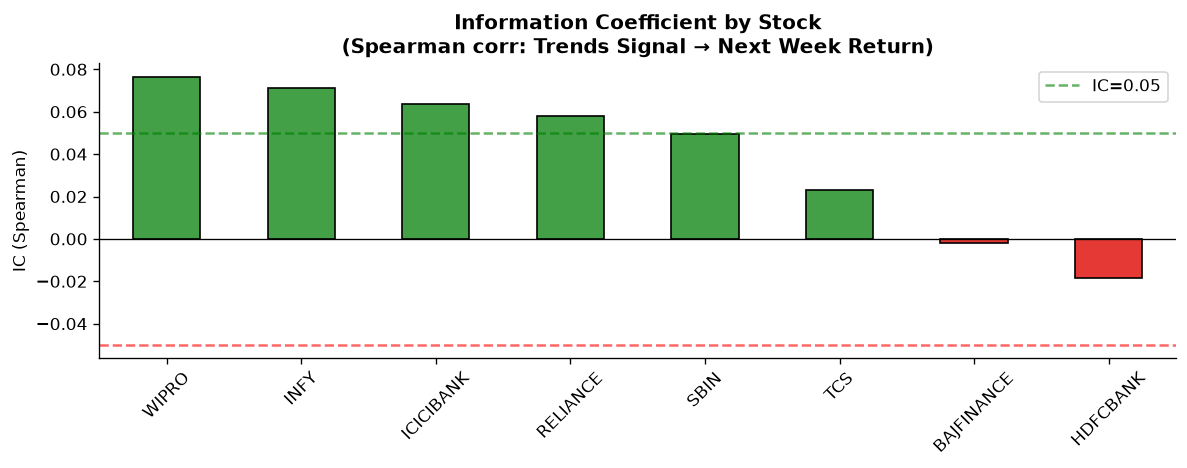

In [27]:
# --- IC bar chart by stock ---
stock_ic = {}
for stock in cols:
    paired = pd.DataFrame({'signal': signal[stock], 'return': R[stock]}).dropna()
    if len(paired) > 10:
        ic_val, _ = stats.spearmanr(paired['signal'], paired['return'])
        stock_ic[stock] = ic_val

ic_bar = pd.Series(stock_ic).sort_values(ascending=False)
colors = ['#43A047' if v > 0 else '#E53935' for v in ic_bar.values]

plt.figure(figsize=(10, 4))
ic_bar.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(0.05, color='green', linestyle='--', alpha=0.6, label='IC=0.05')
plt.axhline(-0.05, color='red', linestyle='--', alpha=0.6)
plt.title('Information Coefficient by Stock\n(Spearman corr: Trends Signal → Next Week Return)',
          fontweight='bold')
plt.ylabel('IC (Spearman)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/ic_by_stock.png', bbox_inches='tight')
plt.show()

## 8. Summary

In [28]:
summary = pd.DataFrame([
    {
        'Strategy':    m['label'],
        'Ann. Return': f"{m['ann_ret']*100:+.2f}%",
        'Ann. Vol':    f"{m['ann_vol']*100:.2f}%",
        'Sharpe':      round(m['sharpe'], 3),
        'Max DD':      f"{m['max_dd']*100:.2f}%",
        'Calmar':      round(m['calmar'], 3),
    }
    for m in [m_strat, m_bh]
])

print('=== Final Performance Summary ===')
print(summary.to_string(index=False))
print(f'\nMean IC  : {mean_ic:.4f}')
print(f'IC IR    : {ic_ir:.4f}')
print(f'IC>0     : {(ic_df["ic"] > 0).mean()*100:.1f}% of weeks')

=== Final Performance Summary ===
               Strategy Ann. Return Ann. Vol  Sharpe  Max DD  Calmar
Long-Short Trends Alpha     +12.79%   22.67%   0.564 -34.85%   0.367
Equal Weight Buy & Hold     +20.87%   19.74%   1.058 -36.08%   0.579

Mean IC  : 0.0437
IC IR    : 0.1001
IC>0     : 53.5% of weeks


## 9. Key Takeaways

1. **Google Trends as alternative data:** Search volume captures retail investor attention — a real, measurable behavioural signal that precedes price moves in some stocks.

2. **Granger causality is a formal test:** We didn't just eyeball correlations. Granger tests whether lagged search volume adds predictive power *beyond* lagged returns alone.

3. **IC measures signal quality:** Mean IC > 0 means the signal has positive predictive content on average. IC IR > 0.5 is considered a strong signal in practice.

4. **Long-short structure removes market beta:** The strategy is market-neutral by construction — returns come purely from the cross-sectional ranking of the trends signal, not from market direction.

5. **Limitations:** pytrends data is relative (0–100 index, not absolute search volume), weekly frequency means slow signal, and Google Trends can be noisy. In practice this would be combined with other signals.

---

### Interview Q&A

**Q: What does Granger causality actually test?**  
A: It tests whether past values of X (search volume) improve the forecast of Y (returns) beyond what past Y alone can explain. It's a predictive test, not a test of true causality.

**Q: Why use z-score normalisation for the trends signal?**  
A: Raw trends are relative (0–100 index), so a score of 80 means different things for different stocks. Rolling z-score puts all stocks on the same scale for cross-sectional ranking.

**Q: What's the IC and why does it matter?**  
A: IC (Information Coefficient) is the Spearman rank correlation between the signal and next-period returns. It measures signal quality independently of position sizing. IC > 0.05 is considered meaningful for weekly signals.

**Q: Why long-short and not just long?**  
A: Long-short removes market beta — returns are driven purely by the cross-sectional signal, not by overall market direction. This makes the alpha more portable and easier to evaluate.